# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

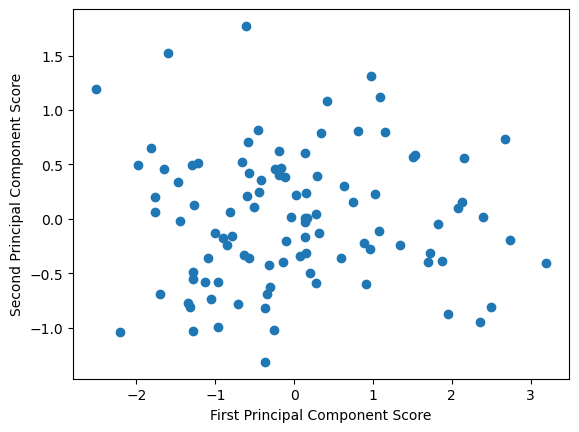

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nayakganesh007/google-ads-sales-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/michaelchen/.cache/kagglehub/datasets/nayakganesh007/google-ads-sales-dataset/versions/1


In [5]:
df = pd.read_csv(os.path.join(path, "GoogleAds_DataAnalytics_Sales_Uncleaned.csv"))

In [7]:
df_clean = df.drop(columns=["Ad_ID", "Campaign_Name", "Location", "Keyword"])
df_clean["Cost"] = df_clean["Cost"].replace('[\$,]', '', regex=True).astype(float)
df_clean["Sale_Amount"] = df_clean["Sale_Amount"].replace(r'[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/_6/sf9_sdv948g9vv933rbbqcgc0000gn/T/ipykernel_17556/4057246251.py:2: SyntaxWarning: invalid escape sequence '\$'
  df_clean["Cost"] = df_clean["Cost"].replace('[\$,]', '', regex=True).astype(float)


In [8]:
from datetime import date

# iterate through the Ad_Date column specifically
for dstr in df_clean["Ad_Date"]:
    # pick separator and split
    if "-" in dstr:
        parts = dstr.split("-")
    else:
        parts = dstr.split("/")

    # convert to datetime.date; pattern depends on which part is year
    if len(parts[0]) == 4:              # YYYY-MM-DD or YYYY/MM/DD
        dt = date(int(parts[0]), int(parts[1]), int(parts[2]))
    else:                                # assume DD-MM-YYYY or DD/MM/YYYY
        dt = date(int(parts[2]), int(parts[1]), int(parts[0]))

    df_clean["Ad_Date"] = dt

df_clean["Device"] = df_clean["Device"].str.lower()

In [9]:
null_like = [None, "", " ", "none", "None", "nan", "NaN", "N/A", "n/a", "null", "NULL"]
df_clean = df_clean.replace(null_like, np.nan)
df_clean = df_clean.dropna()

df_clean

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Device
0,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-22,desktop
1,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,2024-11-22,mobile
6,116.0,4480.0,237.79,17.0,5.0,0.043,1640.0,2024-11-22,tablet
7,184.0,5060.0,229.61,23.0,3.0,0.016,1509.0,2024-11-22,tablet
9,166.0,3355.0,186.78,24.0,9.0,0.054,1029.0,2024-11-22,mobile
...,...,...,...,...,...,...,...,...,...
2594,99.0,4446.0,233.53,11.0,6.0,0.061,1189.0,2024-11-22,tablet
2595,88.0,5344.0,242.07,17.0,9.0,0.054,1418.0,2024-11-22,mobile
2596,154.0,3211.0,248.28,14.0,6.0,0.039,1950.0,2024-11-22,tablet
2597,113.0,3808.0,233.25,18.0,4.0,0.035,1085.0,2024-11-22,desktop


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [11]:
num = df_clean.select_dtypes(include="number")
num

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount
0,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0
1,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0
6,116.0,4480.0,237.79,17.0,5.0,0.043,1640.0
7,184.0,5060.0,229.61,23.0,3.0,0.016,1509.0
9,166.0,3355.0,186.78,24.0,9.0,0.054,1029.0
...,...,...,...,...,...,...,...
2594,99.0,4446.0,233.53,11.0,6.0,0.061,1189.0
2595,88.0,5344.0,242.07,17.0,9.0,0.054,1418.0
2596,154.0,3211.0,248.28,14.0,6.0,0.039,1950.0
2597,113.0,3808.0,233.25,18.0,4.0,0.035,1085.0


<Axes: >

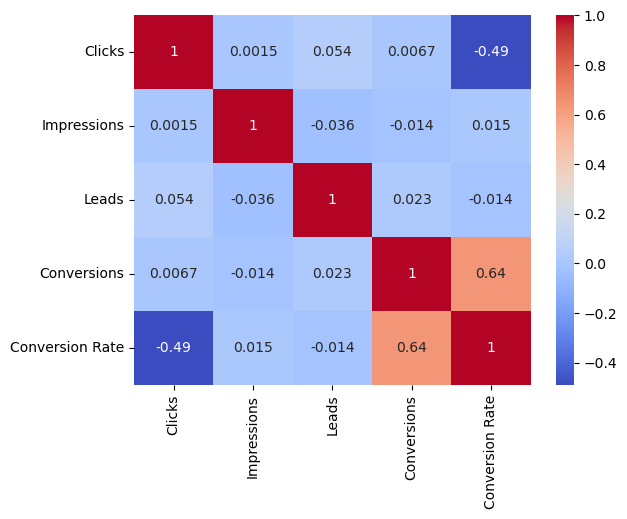

In [14]:
import seaborn as sns
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")


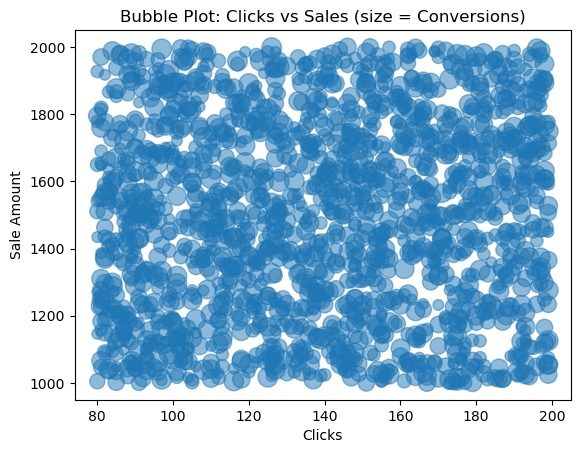

In [19]:
plt.scatter(
    df_clean["Clicks"],
    df_clean["Sale_Amount"],
    s=df_clean["Conversions"] * 20,   # scale size
    alpha=0.5
)

plt.xlabel("Clicks")
plt.ylabel("Sale Amount")
plt.title("Bubble Plot: Clicks vs Sales (size = Conversions)")

plt.show()

In [24]:
num[["Clicks", "Sale_Amount", "Conversions"]]

,Clicks,Sale_Amount,Conversions
0,104.0,1892.0,7.0
1,173.0,1679.0,8.0
6,116.0,1640.0,5.0
7,184.0,1509.0,3.0
9,166.0,1029.0,9.0
...,...,...,...
2594,99.0,1189.0,6.0
2595,88.0,1418.0,9.0
2596,154.0,1950.0,6.0
2597,113.0,1085.0,4.0


In [25]:
pca = decomposition.PCA(n_components = 1)
pca.fit(num)
print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")
mu_h, mu_w, mu_r = num[["Clicks", "Sale_Amount", "Conversions"]].mean().values
print(f"(Clicks, Sale_Amount, Conversions) is approximately equal to ({pca.components_[0][0]:.2} * (Clicks - {mu_h:.2}) + {pca.components_[0][1]:.2} * (Sale_Amount - {mu_w:.2}) + {pca.components_[0][2]:.2} * (Conversions - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")
df_example = num.copy()
df_example["v"] = pca.components_[0][0] * (num["Clicks"] - mu_h) + pca.components_[0][1] * (num["Sale_Amount"] - mu_w) + pca.components_[0][2] * (num["Conversions"] - mu_r)
df_example["Clicks_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["Sale_Amount_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["Conversions_est"] = df_example["v"] * pca.components_[0][2] + mu_r
print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8989985536823545 of the variance
The components_ vector is [a, b, c] = [[-7.14508875e-04  9.99999483e-01  2.21926593e-04 -4.36299402e-04
  -5.48863841e-05  4.27675720e-07  5.30516896e-04]]
(Clicks, Sale_Amount, Conversions) is approximately equal to (-0.00071 * (Clicks - 1.4e+02) + 1.0 * (Sale_Amount - 1.5e+03) + 0.00022 * (Conversions - 6.5)) * (-0.00071, 1.0, 0.00022) + (1.4e+02, 1.5e+03, 6.5)
Examples: (estimating the the vector equals its projection onto the first principal component)
   Clicks  Impressions    Cost  Leads  Conversions  Conversion Rate  \
0   104.0       4498.0  231.88   14.0          7.0            0.058   
1   173.0       5107.0  216.84   10.0          8.0            0.046   
6   116.0       4480.0  237.79   17.0          5.0            0.043   
7   184.0       5060.0  229.61   23.0          3.0            0.016   
9   166.0       3355.0  186.78   24.0          9.0            0.054   

   Sale_Amount           v  Clicks_est

In [27]:
from sklearn import linear_model
from sklearn import metrics

linreg = linear_model.LinearRegression()
linreg.fit(df_clean[['Clicks', 'Sale_Amount']], df_clean['Conversions'])
preds = linreg.predict(df_clean[['Clicks', 'Sale_Amount']])
metrics.mean_squared_error(preds, df_clean['Conversions']) 

5.138077929979275

In [30]:
np.corrcoef(preds, df_clean['Conversions']) 

array([[1.        , 0.02645924],
       [0.02645924, 1.        ]])

I think the one thing that this dataset shows is how synthetic the data is. A lot from the heatmap shows that there isn't any correlation between any of the variables and the bubble map having even distribution shows how inaccurate this dataset is. 

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

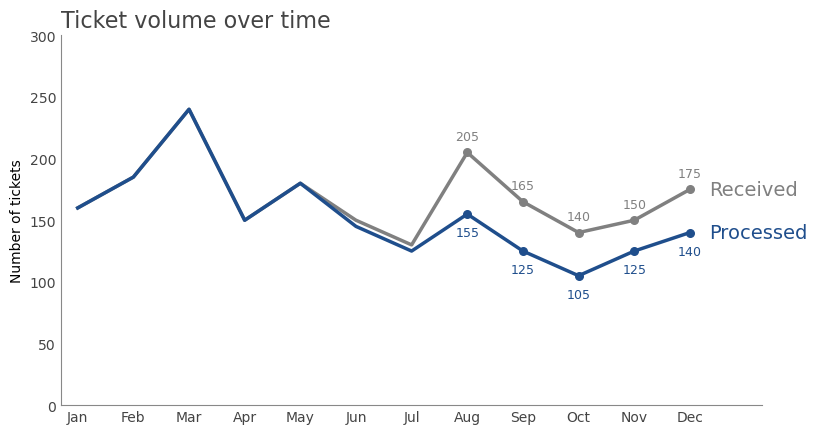

In [33]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

received = [160, 185, 240, 150, 180, 150, 130, 205, 165, 140, 150, 175]
processed = [160, 185, 240, 150, 180, 145, 125, 155, 125, 105, 125, 140]

x = np.arange(len(months))

plt.figure(figsize=(9,5))
ax = plt.gca()

ax.plot(x, received, color="gray", linewidth=2.5)
ax.plot(x, processed, color="#1f4e8c", linewidth=2.5)

highlight_idx = np.array([7, 8, 9, 10, 11])
ax.scatter(highlight_idx, np.array(received)[highlight_idx], color="gray", s=30, zorder=3)
ax.scatter(highlight_idx, np.array(processed)[highlight_idx], color="#1f4e8c", s=30, zorder=3)

for i in highlight_idx:
    ax.text(i, received[i] + 10, str(received[i]), color="gray", ha="center", fontsize=9)
    ax.text(i, processed[i] - 18, str(processed[i]), color="#1f4e8c", ha="center", fontsize=9)

ax.text(11.35, received[-1], "Received", color="gray", va="center", fontsize=14)
ax.text(11.35, processed[-1], "Processed", color="#1f4e8c", va="center", fontsize=14)

ax.set_title("Ticket volume over time", loc="left", fontsize=16, color="#444444")
ax.set_ylabel("Number of tickets", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylim(0, 300)
ax.set_xlim(-0.3, 12.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.tick_params(axis="y", colors="#444444", length=0)
ax.tick_params(axis="x", colors="#444444", length=0)

plt.tight_layout(rect=[0.06, 0.06, 0.98, 0.95])
plt.show()